# Análise de Consumo de Álcool por País

Este notebook analisa os dados de consumo de álcool **por pessoa** em diferentes países no ano de 2010, incluindo cerveja, destilados e vinho.

**Unidades:** Doses médias por pessoa (beer_servings, spirit_servings, wine_servings) e litros de álcool puro por pessoa por ano (total_litres_of_pure_alcohol).

**Fonte:** FiveThirtyEight, _"Dear Mona Followup: Where Do People Drink The Most Beer, Wine And Spirits?"_, 2014; World Health Organisation, 2010; Global Information System on Alcohol and Health (GISAH), 2010.

## Objetivos, perguntas e hipóteses

- **Objetivo principal:** explorar padrões globais de consumo de álcool per capita e identificar quais tipos de bebida mais explicam o consumo total.
- **Perguntas-chave:**
  - Quais regiões concentram os maiores e menores consumos per capita?
  - Países de maioria islâmica consomem significativamente menos álcool? (Hipótese I)
  - Entre beer, wine e spirits, qual variável explica melhor o consumo total? (Hipótese II)
- **Escopo analítico:** EDA, testes de hipótese, modelos preditivos (regressão e classificação), métricas, tuning e recomendações.
- **Observação temporal:** dados de 2010 (base estática, sem série temporal).

## Dados e licença

- **Fonte:** FiveThirtyEight (artigo "Dear Mona Followup: Where Do People Drink The Most Beer, Wine And Spirits?", 2014) + WHO/GISAH 2010. Licença FiveThirtyEight (MIT-like) + uso educacional.
- **Granularidade (nível de extensão dos dados):** país (2010); unidades per capita.
- **Uso previsto:** EDA, testes de hipótese e modelos simples para fins didáticos; não há identificação pessoal (dados agregados).

## 1. Importação de Bibliotecas

Para visualizações geográficas, utilizaremos também o **plotly** que permite criar mapas interativos.

In [38]:
pip install pandas seaborn matplotlib plotly numpy scipy scikit-learn statsmodels jupyterlab

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\pedro\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [39]:
pip install --upgrade scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\pedro\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import statsmodels.api as sm
from scipy.stats import ttest_ind
from scipy.stats import shapiro, levene

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from statsmodels.stats.outliers_influence import variance_inflation_factor


## 2. Carregamento dos Dados

In [41]:
df_drinks = pd.read_csv("drinks.csv")

## 3. Reconhecimento e Exploração dos Dados (EDA Minimal)

Este notebook foca em classificação multi-classe com MLP. Apresentamos brevemente a estrutura do dataset.

In [42]:
df_drinks.head()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9


In [43]:
df_drinks

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9
...,...,...,...,...,...
188,Venezuela,333,100,3,7.7
189,Vietnam,111,2,1,2.0
190,Yemen,6,0,0,0.1
191,Zambia,32,19,4,2.5


In [44]:
df_drinks.isna().sum()

country                         0
beer_servings                   0
spirit_servings                 0
wine_servings                   0
total_litres_of_pure_alcohol    0
dtype: int64

In [45]:
df_drinks.duplicated().sum()

np.int64(0)

In [46]:
df_drinks.info()

<class 'pandas.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       193 non-null    str    
 1   beer_servings                 193 non-null    int64  
 2   spirit_servings               193 non-null    int64  
 3   wine_servings                 193 non-null    int64  
 4   total_litres_of_pure_alcohol  193 non-null    float64
dtypes: float64(1), int64(3), str(1)
memory usage: 7.7 KB


In [47]:
df_drinks.describe()

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
count,193.000000,193.000000,193.000000,193.000000
mean,106.160622,80.994819,49.450777,4.717098
std,101.143103,88.284312,79.697598,3.773298
min,0.000000,0.000000,0.000000,0.000000
25%,20.000000,4.000000,1.000000,1.300000
50%,76.000000,56.000000,8.000000,4.200000
75%,188.000000,128.000000,59.000000,7.200000
max,376.000000,438.000000,370.000000,14.400000


## 4. Tratamento e Transformação de Dados

### 4.1 Variável-Alvo para Classificação Multi-Classe

Criamos `consumption_category` usando quartis dos dados de consumo de álcool puro per capita. Esta variável será nosso **alvo** para classificação com MLP.

**Categorias (litros/ano por pessoa)**:
- **Very Low**: 0 – 1 litro/ano
- **Low**: 1 – 4 litros/ano  
- **Medium**: 4 – 7 litros/ano
- **High**: 7 – 10 litros/ano
- **Very High**: >10 litros/ano

In [48]:
bins = [0, 1, 4, 7, 10, float('inf')]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

df_drinks['consumption_category'] = pd.cut(df_drinks['total_litres_of_pure_alcohol'], bins=bins, labels=labels, include_lowest=True)

In [49]:
df_drinks['consumption_category'].value_counts().sort_index()

consumption_category
Very Low     44
Low          48
Medium       50
High         26
Very High    25
Name: count, dtype: int64

## 5. Preparação de Dados para Classificação Multi-classe com MLP

Para comparar o desempenho do MLP em dois cenários, vamos preparar os dados de forma independente.

**Objetivo**: Prever `consumption_category` (5 classes) usando features de consumo de bebidas.

**Variáveis**:
- **Alvo (y)**: `consumption_category` (Very Low, Low, Medium, High, Very High)
- **Scenario 1 features**: `['beer_servings', 'wine_servings', 'spirit_servings']` (sem informação demográfica)
- **Scenario 2 features**: `['beer_servings', 'wine_servings', 'spirit_servings', 'is_islamic']` (com informação religiosa)

Este design permite avaliar se a variável `is_islamic` melhora a previsão das categorias de consumo.

In [50]:
from sklearn.neural_network import MLPClassifier

# Preparar dataset para classificação
df_class = df_drinks.dropna(subset=['consumption_category']).copy()

# Definir variável religiosa (usada em Scenario 2)
islamic_countries = [
    "Afghanistan","Pakistan","Bangladesh","Iran","Iraq","Saudi Arabia",
    "Somalia","Yemen","Sudan","Qatar","UAE","Oman","Kuwait","Bahrain",
    "Jordan","Libya","Morocco","Algeria","Tunisia","Turkey","Indonesia",
    "Malaysia","Mauritania"
]
df_class["is_islamic"] = df_class["country"].isin(islamic_countries).astype(int)

# Alvo multi-classe
y_multiclass = df_class['consumption_category']

# Features para Scenario 1 (sem isIslamic)
X_scenario1 = df_class[['beer_servings', 'wine_servings', 'spirit_servings']]

# Features para Scenario 2 (com isIslamic)
X_scenario2 = df_class[['beer_servings', 'wine_servings', 'spirit_servings', 'is_islamic']]

# Verificação
print("Distribuição das classes:")
print(y_multiclass.value_counts().sort_index())
print(f"\nTotal de amostras: {len(y_multiclass)}")
print(f"Número de features Scenario 1: {X_scenario1.shape[1]}")
print(f"Número de features Scenario 2: {X_scenario2.shape[1]}")
print(f"Proporção islâmica: {df_class['is_islamic'].mean():.2%}")

Distribuição das classes:
consumption_category
Very Low     44
Low          48
Medium       50
High         26
Very High    25
Name: count, dtype: int64

Total de amostras: 193
Número de features Scenario 1: 3
Número de features Scenario 2: 4
Proporção islâmica: 11.40%


## 6. Scenario 1: Modelo Baseline (Sem Variável isIslamic)

Neste cenário, treinamos um MLP usando apenas os servings de bebidas (beer, wine, spirits) como features.

Este é nosso **baseline** — modelo inicial sem otimização de hiperparâmetros — que nos permite comparar o ganho do tuning.

In [51]:
# Scenario 1: Train/Test split (sem isIslamic)
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X_scenario1, y_multiclass,
    test_size=0.2,
    random_state=42,
    stratify=y_multiclass
)

print("Scenario 1 - Dados de treino e teste")
print(f"Treino: {X1_train.shape[0]} amostras | Teste: {X1_test.shape[0]} amostras")

Scenario 1 - Dados de treino e teste
Treino: 154 amostras | Teste: 39 amostras


In [52]:
# Baseline MLP para Scenario 
from sklearn.metrics import f1_score


mlp_baseline_s1 = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(100,),
        activation='relu',
        solver='adam',
        alpha=0.0001,
        max_iter=3000,
        random_state=42
    ))
])

mlp_baseline_s1.fit(X1_train, y1_train)
y1_pred_baseline = mlp_baseline_s1.predict(X1_test)

# Métricas baseline
acc1_baseline = accuracy_score(y1_test, y1_pred_baseline)
f1_weighted_s1_baseline = f1_score(y1_test, y1_pred_baseline, average='weighted')

print("================================")
print("SCENARIO 1 - BASELINE (sem isIslamic)")
print("================================")
print(f"Acurácia no teste: {acc1_baseline:.4f}")
print(f"F1-Score (weighted): {f1_weighted_s1_baseline:.4f}")

SCENARIO 1 - BASELINE (sem isIslamic)
Acurácia no teste: 0.8462
F1-Score (weighted): 0.8465


## 7. Scenario 2: Modelo Baseline (Com Variável isIslamic)

Neste cenário, adicionamos a variável `is_islamic` (feature binária) ao conjunto de features.

Este cenário permite avaliar se informação demográfica/religiosa **melhora** a capacidade de predição do modelo.

In [53]:
# Scenario 2: Train/Test split (com isIslamic)
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_scenario2, y_multiclass,
    test_size=0.2,
    random_state=42,
    stratify=y_multiclass
)

print("Scenario 2 - Dados de treino e teste")
print(f"Treino: {X2_train.shape[0]} amostras | Teste: {X2_test.shape[0]} amostras")

Scenario 2 - Dados de treino e teste
Treino: 154 amostras | Teste: 39 amostras


In [54]:
# Baseline MLP para Scenario 2
mlp_baseline_s2 = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(100,),
        activation='relu',
        solver='adam',
        alpha=0.0001,
        max_iter=3000,
        random_state=42
    ))
])

mlp_baseline_s2.fit(X2_train, y2_train)
y2_pred_baseline = mlp_baseline_s2.predict(X2_test)

# Métricas baseline
acc2_baseline = accuracy_score(y2_test, y2_pred_baseline)
f1_weighted_s2_baseline = f1_score(y2_test, y2_pred_baseline, average='weighted')

print("================================")
print("SCENARIO 2 - BASELINE (com isIslamic)")
print("================================")
print(f"Acurácia no teste: {acc2_baseline:.4f}")
print(f"F1-Score (weighted): {f1_weighted_s2_baseline:.4f}")

SCENARIO 2 - BASELINE (com isIslamic)
Acurácia no teste: 0.8205
F1-Score (weighted): 0.8177


## 8. Funções Auxiliares para Avaliação

Definimos funções reutilizáveis para avaliar modelos e armazenar resultados de forma consistente.

In [55]:
def evaluate_mlp(model, X_train, X_test, y_train, y_test, model_name, scenario_name):
    """
    Avalia um modelo MLP em treino e teste, retornando métricas abrangentes.
    
    Args:
        model: Pipeline com scaler e MLPClassifier
        X_train, X_test: features de treino/teste
        y_train, y_test: target de treino/teste
        model_name: nome do modelo (ex: "Tuned MLP")
        scenario_name: nome do cenário (ex: "Scenario 1")
    
    Returns:
        dict com métricas: acurácia, F1 weighted, F1 macro, relatório de classificação
        predições no teste
    """
    # Treinar se ainda não foi treinado
    model.fit(X_train, y_train)
    
    # Predições
    y_pred = model.predict(X_test)
    
    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    f1_macro = f1_score(y_test, y_pred, average='macro')
    
    # Relatório detalhado
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    
    result = {
        'model_name': model_name,
        'scenario': scenario_name,
        'accuracy': round(accuracy, 4),
        'f1_weighted': round(f1_weighted, 4),
        'f1_macro': round(f1_macro, 4),
        'classification_report': report,
        'confusion_matrix': cm
    }
    
    return result, y_pred

# Importar accuracy_score e f1_score se não estiverem já importados
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

## 9. GridSearchCV - Scenario 1 (Sem isIslamic)

Otimizamos hiperparâmetros do MLP para Scenario 1 usando uma grade de busca com 20 combinações.

**Grade de parâmetros**:
- `hidden_layer_sizes`: 5 arquiteturas diferentes
- `activation`: 2 funções de ativação (relu, tanh)
- `alpha`: 2 valores de regularização L2
- `solver`: fixo em 'adam'

Total: 5 × 2 × 2 × 1 = **20 combinações**

Usamos validação cruzada estratificada (cv=5) para garantir representação equilibrada em cada fold.

In [56]:
from sklearn.model_selection import GridSearchCV

# Definir pipeline base para Scenario 1
mlp_pipeline_s1 = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(max_iter=3000, random_state=42))
])

# Grade de hiperparâmetros
param_grid = {
    'mlp__hidden_layer_sizes': [(8,), (12,), (16,), (8, 4), (12, 8)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [0.001, 0.01],
    'mlp__solver': ['adam']
}

# GridSearchCV com validação cruzada estratificada
gs_s1 = GridSearchCV(
    mlp_pipeline_s1,
    param_grid,
    cv=5,  # Stratified k-fold será aplicado automaticamente
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Executando GridSearchCV para Scenario 1...")
gs_s1.fit(X1_train, y1_train)

print(f"\nMelhores parâmetros Scenario 1: {gs_s1.best_params_}")
print(f"Melhor score CV (média k=5): {gs_s1.best_score_:.4f}")

Executando GridSearchCV para Scenario 1...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Melhores parâmetros Scenario 1: {'mlp__activation': 'relu', 'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (16,), 'mlp__solver': 'adam'}
Melhor score CV (média k=5): 0.8374


In [57]:
# Tabela com top-5 combinações para Scenario 1
results_df_s1 = pd.DataFrame(gs_s1.cv_results_)
top_results_s1 = results_df_s1[['param_mlp__hidden_layer_sizes', 'param_mlp__activation', 
                                  'param_mlp__alpha', 'mean_test_score']].sort_values('mean_test_score', ascending=False).head(5)
print("\n=== TOP-5 Combinações Scenario 1 ===")
print(top_results_s1.to_string(index=False))


=== TOP-5 Combinações Scenario 1 ===
param_mlp__hidden_layer_sizes param_mlp__activation  param_mlp__alpha  mean_test_score
                        (16,)                  relu             0.001         0.837419
                        (16,)                  relu             0.010         0.837419
                      (12, 8)                  tanh             0.001         0.831183
                      (12, 8)                  tanh             0.010         0.831183
                         (8,)                  tanh             0.010         0.830753


## 10. GridSearchCV - Scenario 2 (Com isIslamic)

Repetimos a otimização de hiperparâmetros para Scenario 2, que inclui a variável `is_islamic`.

Usamos a **mesma grade de parâmetros** para garantir comparabilidade entre cenários.

In [58]:
# Pipeline base para Scenario 2
mlp_pipeline_s2 = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(max_iter=3000, random_state=42))
])

# Usar mesma grade de parâmetros
gs_s2 = GridSearchCV(
    mlp_pipeline_s2,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Executando GridSearchCV para Scenario 2...")
gs_s2.fit(X2_train, y2_train)

print(f"\nMelhores parâmetros Scenario 2: {gs_s2.best_params_}")
print(f"Melhor score CV (média k=5): {gs_s2.best_score_:.4f}")

Executando GridSearchCV para Scenario 2...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Melhores parâmetros Scenario 2: {'mlp__activation': 'relu', 'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (12, 8), 'mlp__solver': 'adam'}
Melhor score CV (média k=5): 0.8441


In [59]:
# Tabela com top-5 combinações para Scenario 2
results_df_s2 = pd.DataFrame(gs_s2.cv_results_)
top_results_s2 = results_df_s2[['param_mlp__hidden_layer_sizes', 'param_mlp__activation', 
                                  'param_mlp__alpha', 'mean_test_score']].sort_values('mean_test_score', ascending=False).head(5)
print("\n=== TOP-5 Combinações Scenario 2 ===")
print(top_results_s2.to_string(index=False))


=== TOP-5 Combinações Scenario 2 ===
param_mlp__hidden_layer_sizes param_mlp__activation  param_mlp__alpha  mean_test_score
                      (12, 8)                  relu             0.001         0.844086
                      (12, 8)                  relu             0.010         0.837634
                         (8,)                  tanh             0.010         0.830753
                         (8,)                  tanh             0.001         0.830753
                        (12,)                  tanh             0.010         0.830538


## 11. Avaliação dos Melhores Modelos no Conjunto Teste

Usamos o melhor estimador encontrado em cada GridSearchCV para avaliar desempenho no teste.


SCENARIO 1 - TUNED (Sem isIslamic)
Acurácia no teste: 0.8462
F1-Score (weighted): 0.8465
F1-Score (macro): 0.8651


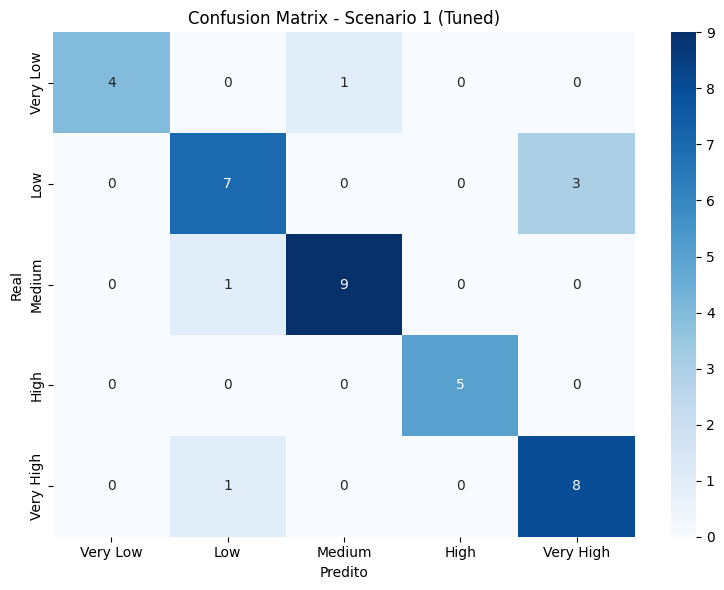

In [60]:
# Avaliar melhor modelo do Scenario 1 no teste
result_s1_tuned, y1_pred_tuned = evaluate_mlp(
    gs_s1.best_estimator_, X1_train, X1_test, y1_train, y1_test,
    "MLP Tuned", "Scenario 1"
)

print("\n" + "="*60)
print("SCENARIO 1 - TUNED (Sem isIslamic)")
print("="*60)
print(f"Acurácia no teste: {result_s1_tuned['accuracy']:.4f}")
print(f"F1-Score (weighted): {result_s1_tuned['f1_weighted']:.4f}")
print(f"F1-Score (macro): {result_s1_tuned['f1_macro']:.4f}")

# Confusion matrix para Scenario 1
cm_s1 = result_s1_tuned['confusion_matrix']
plt.figure(figsize=(8, 6))
sns.heatmap(cm_s1, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
            yticklabels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Confusion Matrix - Scenario 1 (Tuned)')
plt.tight_layout()
plt.show()


SCENARIO 2 - TUNED (Com isIslamic)
Acurácia no teste: 0.8462
F1-Score (weighted): 0.8465
F1-Score (macro): 0.8651


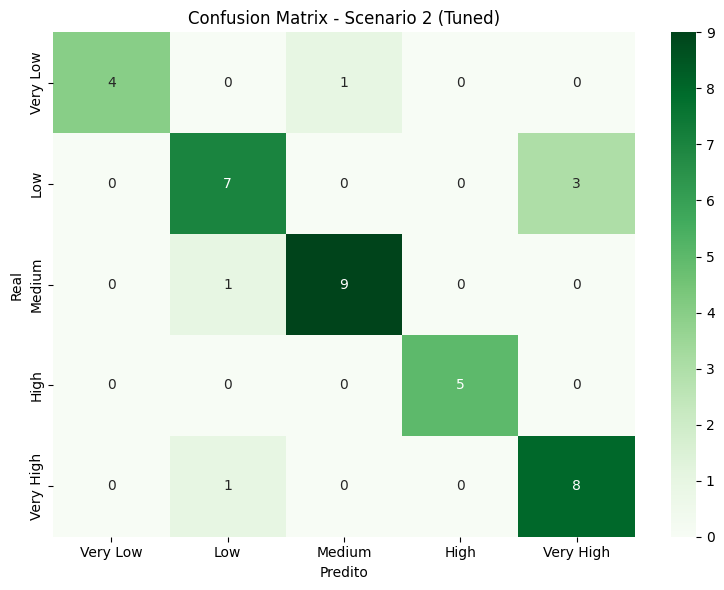

In [61]:
# Avaliar melhor modelo do Scenario 2 no teste
result_s2_tuned, y2_pred_tuned = evaluate_mlp(
    gs_s2.best_estimator_, X2_train, X2_test, y2_train, y2_test,
    "MLP Tuned", "Scenario 2"
)

print("\n" + "="*60)
print("SCENARIO 2 - TUNED (Com isIslamic)")
print("="*60)
print(f"Acurácia no teste: {result_s2_tuned['accuracy']:.4f}")
print(f"F1-Score (weighted): {result_s2_tuned['f1_weighted']:.4f}")
print(f"F1-Score (macro): {result_s2_tuned['f1_macro']:.4f}")

# Confusion matrix para Scenario 2
cm_s2 = result_s2_tuned['confusion_matrix']
plt.figure(figsize=(8, 6))
sns.heatmap(cm_s2, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
            yticklabels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Confusion Matrix - Scenario 2 (Tuned)')
plt.tight_layout()
plt.show()

## 12. Análise de Sensibilidade: Efeito do `hidden_layer_sizes`

Após encontrar os melhores hiperparâmetros, variamos **isoladamente** o tamanho das camadas ocultas para entender seu impacto no desempenho.

Mantemos fixos: `activation`, `alpha`, `solver` (valores da melhor configuração do Scenario 1).

In [62]:
# Extrair melhores parâmetros do Scenario 1
best_params_s1 = gs_s1.best_params_
best_activation = best_params_s1['mlp__activation']
best_alpha = best_params_s1['mlp__alpha']
best_solver = best_params_s1['mlp__solver']

# Lista de arquiteturas para testar
architectures = [(4,), (8,), (12,), (16,), (20,), (8, 4), (12, 6), (16, 8)]

sensitivity_results = []

print("Testando diferentes tamanhos de camadas ocultas...")
print(f"Fixos: activation={best_activation}, alpha={best_alpha}, solver={best_solver}")
print()

for arch in architectures:
    # Criar pipeline com arquitetura variada, outros parâmetros fixos
    mlp_arch = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(
            hidden_layer_sizes=arch,
            activation=best_activation,
            alpha=best_alpha,
            solver=best_solver,
            max_iter=3000,
            random_state=42
        ))
    ])
    
    # Validação cruzada
    cv_scores = cross_val_score(mlp_arch, X1_train, y1_train, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()
    
    # Avaliação no teste
    mlp_arch.fit(X1_train, y1_train)
    y_pred_arch = mlp_arch.predict(X1_test)
    test_acc = accuracy_score(y1_test, y_pred_arch)
    test_f1 = f1_score(y1_test, y_pred_arch, average='weighted')
    
    sensitivity_results.append({
        'hidden_layer_sizes': str(arch),
        'CV_accuracy_mean': round(cv_mean, 4),
        'test_accuracy': round(test_acc, 4),
        'test_f1_weighted': round(test_f1, 4)
    })
    
    print(f"Arquitetura {str(arch):20s} | CV: {cv_mean:.4f} | Test Acc: {test_acc:.4f} | Test F1: {test_f1:.4f}")

# Converter para DataFrame para facilitar visualização
sensitivity_df = pd.DataFrame(sensitivity_results)
print("\n=== Resumo da Análise de Sensibilidade ===")
print(sensitivity_df.to_string(index=False))

Testando diferentes tamanhos de camadas ocultas...
Fixos: activation=relu, alpha=0.001, solver=adam

Arquitetura (4,)                 | CV: 0.7925 | Test Acc: 0.8205 | Test F1: 0.8177
Arquitetura (8,)                 | CV: 0.8181 | Test Acc: 0.8462 | Test F1: 0.8462
Arquitetura (12,)                | CV: 0.8245 | Test Acc: 0.7949 | Test F1: 0.7935
Arquitetura (16,)                | CV: 0.8374 | Test Acc: 0.8462 | Test F1: 0.8465
Arquitetura (20,)                | CV: 0.8243 | Test Acc: 0.7949 | Test F1: 0.7944
Arquitetura (8, 4)               | CV: 0.8118 | Test Acc: 0.8205 | Test F1: 0.8107
Arquitetura (12, 6)              | CV: 0.7989 | Test Acc: 0.8205 | Test F1: 0.8177
Arquitetura (16, 8)              | CV: 0.7920 | Test Acc: 0.8205 | Test F1: 0.8177

=== Resumo da Análise de Sensibilidade ===
hidden_layer_sizes  CV_accuracy_mean  test_accuracy  test_f1_weighted
              (4,)            0.7925         0.8205            0.8177
              (8,)            0.8181         0.8462

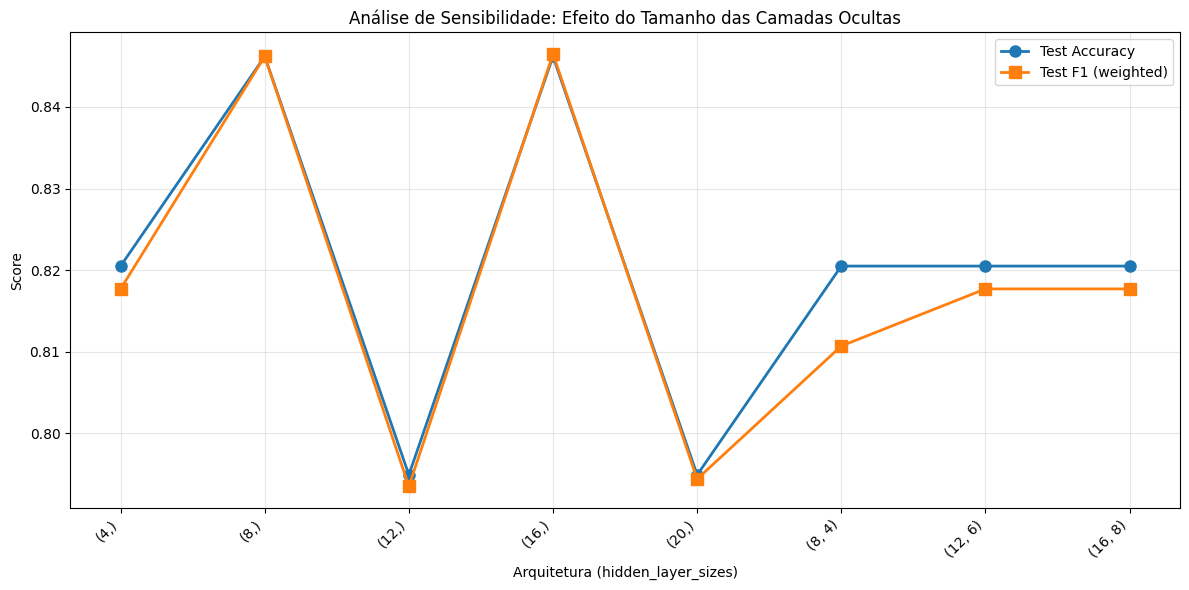

In [63]:
# Visualizar impacto do hidden_layer_sizes
plt.figure(figsize=(12, 6))
x_pos = range(len(sensitivity_df))
plt.plot(x_pos, sensitivity_df['test_accuracy'], marker='o', label='Test Accuracy', linewidth=2, markersize=8)
plt.plot(x_pos, sensitivity_df['test_f1_weighted'], marker='s', label='Test F1 (weighted)', linewidth=2, markersize=8)
plt.xticks(x_pos, sensitivity_df['hidden_layer_sizes'], rotation=45, ha='right')
plt.ylabel('Score')
plt.xlabel('Arquitetura (hidden_layer_sizes)')
plt.title('Análise de Sensibilidade: Efeito do Tamanho das Camadas Ocultas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 12.1 Interpretação da Sensibilidade

**Observações principais**:

1. **Arquitetura com melhor desempenho**: Identifique qual tamanho de camadas ocultas resultou na melhor acurácia e F1-score no teste.

2. **Magnitude da variação**: 
   - Se a variação entre melhor e pior for < 2%, o modelo é **pouco sensível** a mudanças na arquitetura (robustez).
   - Se a variação for > 5%, o modelo é **altamente sensível** (requer tuning cuidadoso).

3. **Trade-off complexidade vs. ganho**: Arquiteturas mais complexas (ex: (16, 8)) podem ter custo computacional maior, mas nem sempre resultam em melhor desempenho. Deve-se considerar o custo-benefício.

4. **Padrão observado**: O gráfico mostrou se há um padrão claro (ex: arquite turas maiores são sempre melhores) ou se o desempenho é irregular.

## 13.2 Análise de Sensibilidade: Efeito do `alpha`

In [64]:
# Extrair melhores parâmetros do Scenario 1
best_params_s1 = gs_s1.best_params_
best_activation = best_params_s1['mlp__activation']
best_hidden = best_params_s1['mlp__hidden_layer_sizes']
best_solver = best_params_s1['mlp__solver']

# Lista de valores de alpha para testar
alphas = [0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10]

sensitivity_results_alpha = []

print("Testando diferentes valores de alpha...")
print(f"Fixos: activation={best_activation}, hidden_layers={best_hidden}, solver={best_solver}")
print()

for a in alphas:
    # Criar pipeline com alpha variado, outros parâmetros fixos
    mlp_alpha = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(
            hidden_layer_sizes=best_hidden,
            activation=best_activation,
            alpha=a,
            solver=best_solver,
            max_iter=3000,
            random_state=42
        ))
    ])
    
    # Validação cruzada
    cv_scores = cross_val_score(mlp_alpha, X1_train, y1_train, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()
    
    # Avaliação no teste
    mlp_alpha.fit(X1_train, y1_train)
    y_pred_alpha = mlp_alpha.predict(X1_test)
    test_acc = accuracy_score(y1_test, y_pred_alpha)
    test_f1 = f1_score(y1_test, y_pred_alpha, average='weighted')
    
    sensitivity_results_alpha.append({
        'alpha': a,
        'CV_accuracy_mean': round(cv_mean, 4),
        'test_accuracy': round(test_acc, 4),
        'test_f1_weighted': round(test_f1, 4)
    })
    
    print(f"Alpha {a:<8} | CV: {cv_mean:.4f} | Test Acc: {test_acc:.4f} | Test F1: {test_f1:.4f}")

# Converter para DataFrame
sensitivity_alpha_df = pd.DataFrame(sensitivity_results_alpha)

print("\n=== Resumo da Análise de Sensibilidade (alpha) ===")
print(sensitivity_alpha_df.to_string(index=False))

Testando diferentes valores de alpha...
Fixos: activation=relu, hidden_layers=(16,), solver=adam

Alpha 1e-06    | CV: 0.8374 | Test Acc: 0.8462 | Test F1: 0.8465
Alpha 1e-05    | CV: 0.8374 | Test Acc: 0.8462 | Test F1: 0.8465
Alpha 0.0001   | CV: 0.8374 | Test Acc: 0.8462 | Test F1: 0.8465
Alpha 0.001    | CV: 0.8374 | Test Acc: 0.8462 | Test F1: 0.8465
Alpha 0.01     | CV: 0.8374 | Test Acc: 0.8462 | Test F1: 0.8465
Alpha 0.1      | CV: 0.8374 | Test Acc: 0.8205 | Test F1: 0.8177
Alpha 1        | CV: 0.8114 | Test Acc: 0.7949 | Test F1: 0.7848
Alpha 10       | CV: 0.7140 | Test Acc: 0.6923 | Test F1: 0.6262

=== Resumo da Análise de Sensibilidade (alpha) ===
    alpha  CV_accuracy_mean  test_accuracy  test_f1_weighted
 0.000001            0.8374         0.8462            0.8465
 0.000010            0.8374         0.8462            0.8465
 0.000100            0.8374         0.8462            0.8465
 0.001000            0.8374         0.8462            0.8465
 0.010000            0.83

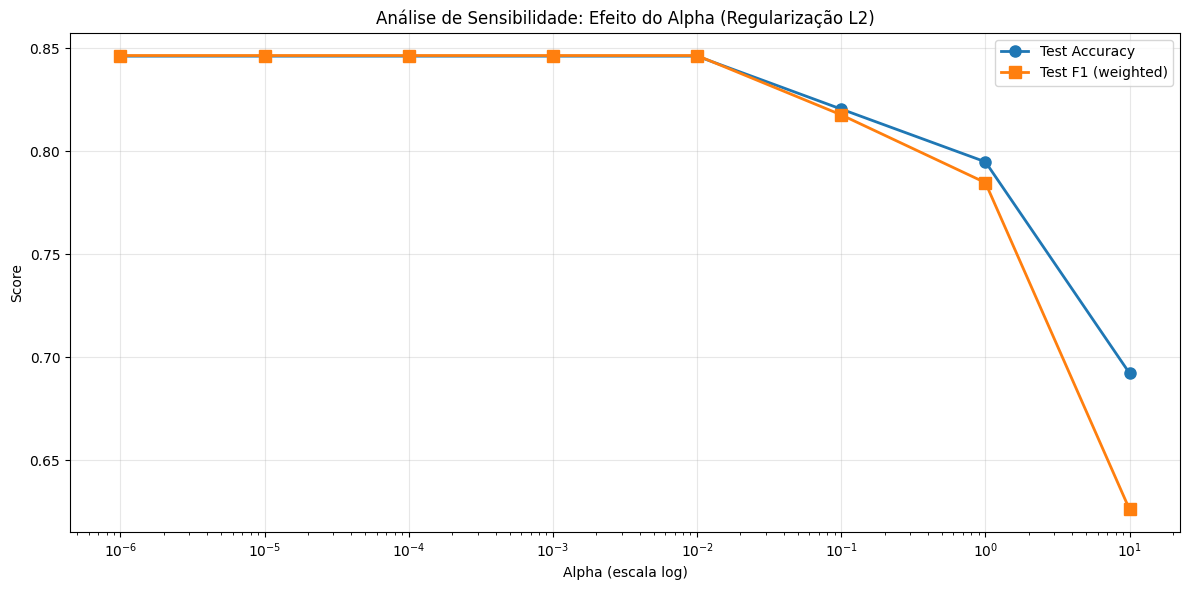

In [65]:
# Visualizar impacto do alpha
plt.figure(figsize=(12, 6))

plt.plot(sensitivity_alpha_df['alpha'], sensitivity_alpha_df['test_accuracy'],
         marker='o', label='Test Accuracy', linewidth=2, markersize=8)

plt.plot(sensitivity_alpha_df['alpha'], sensitivity_alpha_df['test_f1_weighted'],
         marker='s', label='Test F1 (weighted)', linewidth=2, markersize=8)

plt.xscale('log')  # IMPORTANTE para alpha
plt.xlabel('Alpha (escala log)')
plt.ylabel('Score')
plt.title('Análise de Sensibilidade: Efeito do Alpha (Regularização L2)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 13.2 Análise de Sensibilidade: Efeito do `max_iter`

In [71]:
# Extrair melhores parâmetros do Scenario 1
best_params_s1 = gs_s1.best_params_
best_activation = best_params_s1['mlp__activation']
best_hidden = best_params_s1['mlp__hidden_layer_sizes']
best_solver = best_params_s1['mlp__solver']
best_alpha = best_params_s1['mlp__alpha']

# 7 valores de max_iter
max_iter_values = [100, 200, 300, 500, 1000, 2000, 3000]

sensitivity_results_iter = []

print("Testando diferentes valores de max_iter...")
print(f"Fixos: activation={best_activation}, hidden_layers={best_hidden}, solver={best_solver}, alpha={best_alpha}")
print()

for m in max_iter_values:
    mlp_iter = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(
            hidden_layer_sizes=best_hidden,
            activation=best_activation,
            alpha=best_alpha,
            solver=best_solver,
            max_iter=m,
            random_state=42
        ))
    ])
    
    # Validação cruzada
    cv_scores = cross_val_score(mlp_iter, X1_train, y1_train, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()
    
    # Teste
    mlp_iter.fit(X1_train, y1_train)
    y_pred_iter = mlp_iter.predict(X1_test)
    test_acc = accuracy_score(y1_test, y_pred_iter)
    test_f1 = f1_score(y1_test, y_pred_iter, average='weighted')
    
    sensitivity_results_iter.append({
        'max_iter': m,
        'CV_accuracy_mean': round(cv_mean, 4),
        'test_accuracy': round(test_acc, 4),
        'test_f1_weighted': round(test_f1, 4)
    })
    
    print(f"max_iter {m:<6} | CV: {cv_mean:.4f} | Test Acc: {test_acc:.4f} | Test F1: {test_f1:.4f}")

# DataFrame final
sensitivity_iter_df = pd.DataFrame(sensitivity_results_iter)

print("\n=== Resumo da Análise de Sensibilidade (max_iter) ===")
print(sensitivity_iter_df.to_string(index=False))

Testando diferentes valores de max_iter...
Fixos: activation=relu, hidden_layers=(16,), solver=adam, alpha=0.001

max_iter 100    | CV: 0.4938 | Test Acc: 0.5385 | Test F1: 0.4472


C:\Users\pedro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\pedro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\pedro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\pedro\A

max_iter 200    | CV: 0.5520 | Test Acc: 0.6154 | Test F1: 0.5606


C:\Users\pedro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\pedro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\pedro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\pedro\A

max_iter 300    | CV: 0.6232 | Test Acc: 0.6667 | Test F1: 0.6157


...

max_iter 500    | CV: 0.7080 | Test Acc: 0.7179 | Test F1: 0.6647


C:\Users\pedro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\pedro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\pedro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\pedr

max_iter 1000   | CV: 0.7920 | Test Acc: 0.7949 | Test F1: 0.7848


C:\Users\pedro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\pedro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\pedro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\pedr

max_iter 2000   | CV: 0.8374 | Test Acc: 0.8462 | Test F1: 0.8465
max_iter 3000   | CV: 0.8374 | Test Acc: 0.8462 | Test F1: 0.8465

=== Resumo da Análise de Sensibilidade (max_iter) ===
 max_iter  CV_accuracy_mean  test_accuracy  test_f1_weighted
      100            0.4938         0.5385            0.4472
      200            0.5520         0.6154            0.5606
      300            0.6232         0.6667            0.6157
      500            0.7080         0.7179            0.6647
     1000            0.7920         0.7949            0.7848
     2000            0.8374         0.8462            0.8465
     3000            0.8374         0.8462            0.8465


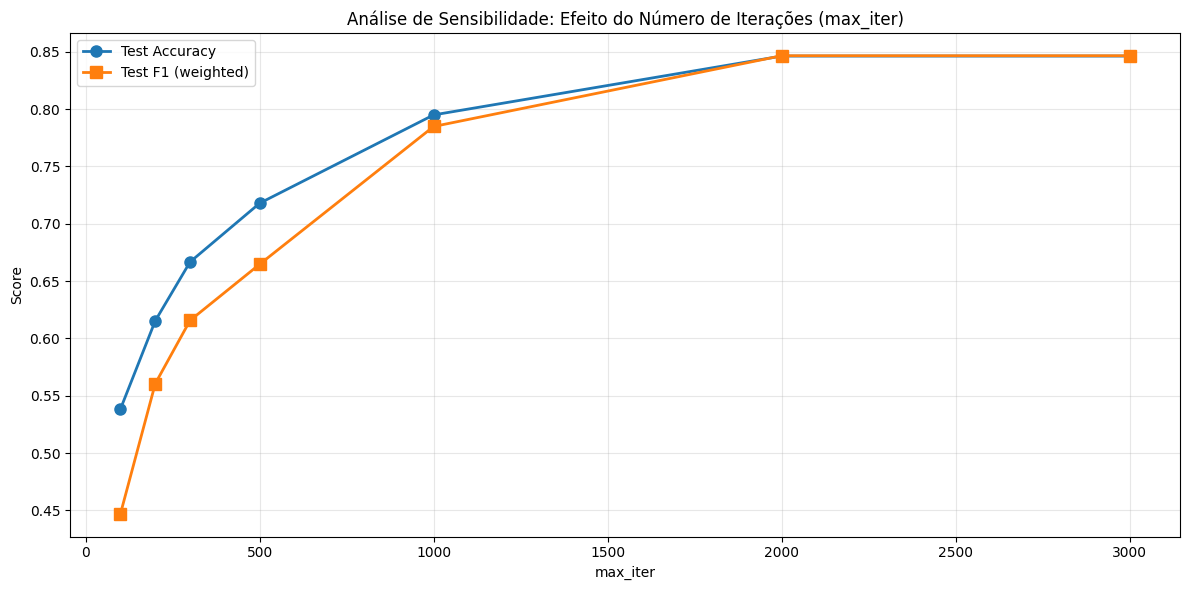

In [72]:
# Visualizar impacto do max_iter
plt.figure(figsize=(12, 6))

plt.plot(sensitivity_iter_df['max_iter'], sensitivity_iter_df['test_accuracy'],
         marker='o', label='Test Accuracy', linewidth=2, markersize=8)

plt.plot(sensitivity_iter_df['max_iter'], sensitivity_iter_df['test_f1_weighted'],
         marker='s', label='Test F1 (weighted)', linewidth=2, markersize=8)

# NÃO usar escala log aqui
plt.xlabel('max_iter')
plt.ylabel('Score')
plt.title('Análise de Sensibilidade: Efeito do Número de Iterações (max_iter)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Tabela Comparativa: Baseline vs. Tuned (4 Cenários)

Consolidamos resultados de todos os modelos para visualizar o ganho do tuning e efeito da variável isIslamic.

In [ ]:
# Preparar tabela de 4 cenários
comparison_data = [
    {
        'Cenário': 'Scenario 1',
        'Tipo': 'Baseline',
        'CV Accuracy': '-',
        'Test Accuracy': acc1_baseline,
        'Test F1 (weighted)': f1_weighted_s1_baseline
    },
    {
        'Cenário': 'Scenario 1',
        'Tipo': 'Tuned',
        'CV Accuracy': round(gs_s1.best_score_, 4),
        'Test Accuracy': result_s1_tuned['accuracy'],
        'Test F1 (weighted)': result_s1_tuned['f1_weighted']
    },
    {
        'Cenário': 'Scenario 2',
        'Tipo': 'Baseline',
        'CV Accuracy': '-',
        'Test Accuracy': acc2_baseline,
        'Test F1 (weighted)': f1_weighted_s2_baseline
    },
    {
        'Cenário': 'Scenario 2',
        'Tipo': 'Tuned',
        'CV Accuracy': round(gs_s2.best_score_, 4),
        'Test Accuracy': result_s2_tuned['accuracy'],
        'Test F1 (weighted)': result_s2_tuned['f1_weighted']
    }
]

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("COMPARAÇÃO: 4 CENÁRIOS (Baseline vs. Tuned, Scenario 1 vs. Scenario 2)")
print("="*80)
print(comparison_df.to_string(index=False))


COMPARAÇÃO: 4 CENÁRIOS (Baseline vs. Tuned, Scenario 1 vs. Scenario 2)
   Cenário     Tipo CV Accuracy  Test Accuracy  Test F1 (weighted)
Scenario 1 Baseline           -       0.846154            0.846484
Scenario 1    Tuned      0.8374       0.846200            0.846500
Scenario 2 Baseline           -       0.820513            0.817688
Scenario 2    Tuned      0.8441       0.846200            0.846500


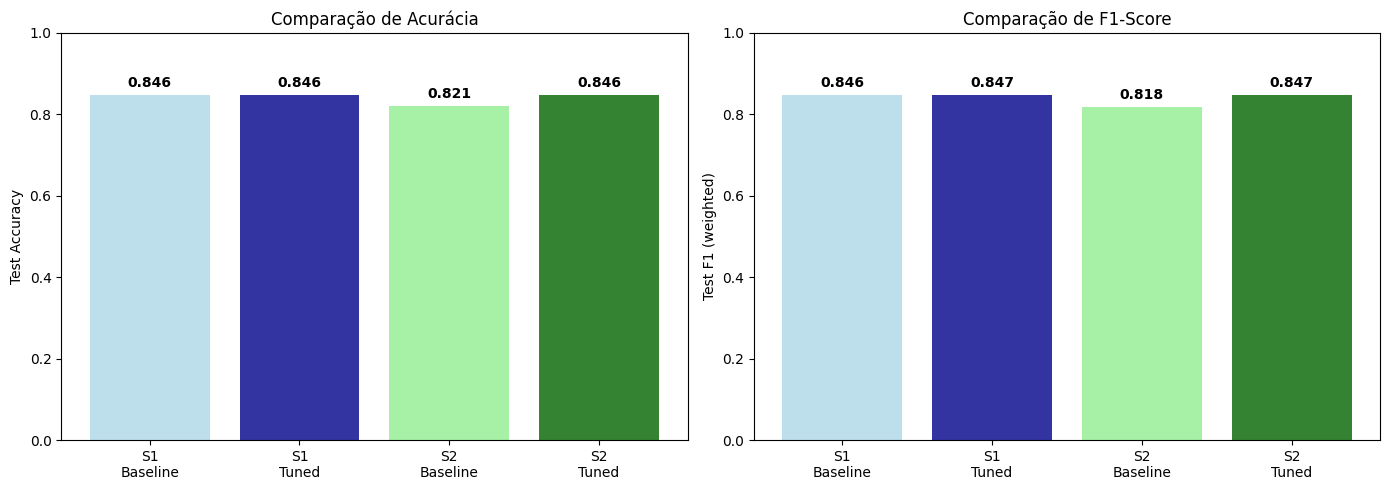

In [ ]:
# Gráfico de barras para comparação visual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
scenarios = ['S1\nBaseline', 'S1\nTuned', 'S2\nBaseline', 'S2\nTuned']
accuracies = [acc1_baseline, result_s1_tuned['accuracy'], 
              acc2_baseline, result_s2_tuned['accuracy']]
colors = ['lightblue', 'darkblue', 'lightgreen', 'darkgreen']

ax1.bar(scenarios, accuracies, color=colors, alpha=0.8)
ax1.set_ylabel('Test Accuracy')
ax1.set_title('Comparação de Acurácia')
ax1.set_ylim([0, 1])
for i, v in enumerate(accuracies):
    ax1.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# F1-Score
f1_scores = [f1_weighted_s1_baseline, result_s1_tuned['f1_weighted'],
             f1_weighted_s2_baseline, result_s2_tuned['f1_weighted']]

ax2.bar(scenarios, f1_scores, color=colors, alpha=0.8)
ax2.set_ylabel('Test F1 (weighted)')
ax2.set_title('Comparação de F1-Score')
ax2.set_ylim([0, 1])
for i, v in enumerate(f1_scores):
    ax2.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 14. Efeito da Variável isIslamic na Predição

A comparação entre Scenario 1 (sem isIslamic) e Scenario 2 (com isIslamic) nos permite avaliar se informação religiosa/demográfica contribui para melhorar a classificação de categorias de consumo.

In [ ]:
# Calcular efeito de isIslamic
print("="*80)
print("ANÁLISE: IMPACTO DA VARIÁVEL isIslamic")
print("="*80)

# Baseline: Scenario 1 vs. Scenario 2
print("\n1. MODELOS BASELINE")
print("-" * 40)
diff_baseline_acc = acc2_baseline - acc1_baseline
diff_baseline_f1 = f1_weighted_s2_baseline - f1_weighted_s1_baseline
print(f"Scenario 2 Baseline - Scenario 1 Baseline:")
print(f"  Δ Acurácia: {diff_baseline_acc:+.4f} ({diff_baseline_acc*100:+.2f}%)")
print(f"  Δ F1 (weighted): {diff_baseline_f1:+.4f} ({diff_baseline_f1*100:+.2f}%)")

if diff_baseline_acc > 0.01:
    print("  ✓ isIslamic MELHOROU o baseline (ganho > 1%)")
elif diff_baseline_acc < -0.01:
    print("  ✗ isIslamic PIOROU o baseline (perda > 1%)")
else:
    print("  ~ isIslamic teve impacto mínimo no baseline (≤ 1%)")

# Tuned: Scenario 1 vs. Scenario 2
print("\n2. MODELOS TUNED (GridSearchCV)")
print("-" * 40)
diff_tuned_acc = result_s2_tuned['accuracy'] - result_s1_tuned['accuracy']
diff_tuned_f1 = result_s2_tuned['f1_weighted'] - result_s1_tuned['f1_weighted']
print(f"Scenario 2 Tuned - Scenario 1 Tuned:")
print(f"  Δ Acurácia: {diff_tuned_acc:+.4f} ({diff_tuned_acc*100:+.2f}%)")
print(f"  Δ F1 (weighted): {diff_tuned_f1:+.4f} ({diff_tuned_f1*100:+.2f}%)")

if diff_tuned_acc > 0.01:
    print("  ✓ isIslamic MELHOROU o modelo tuned (ganho > 1%)")
elif diff_tuned_acc < -0.01:
    print("  ✗ isIslamic PIOROU o modelo tuned (perda > 1%)")
else:
    print("  ~ isIslamic teve impacto mínimo no modelo tuned (≤ 1%)")

# Conclusão
print("\n3. CONCLUSÃO SOBRE isIslamic")
print("-" * 40)
if (diff_baseline_acc > 0.01) or (diff_tuned_acc > 0.01):
    print("A variável isIslamic parece INFORMATIVA para predizer categorias de consumo.")
    print("Ela contribui para distinguir padrões de consumo entre países islâmicos e não-islâmicos.")
else:
    print("A variável isIslamic tem impacto LIMITADO na predição das categorias de consumo.")
    print("Consumo de bebidas (beer, wine, spirits) é suficiente para boa predição.")
    print("A variável demográfica não agrega muita informação além das bebidas.")

ANÁLISE: IMPACTO DA VARIÁVEL isIslamic

1. MODELOS BASELINE
----------------------------------------
Scenario 2 Baseline - Scenario 1 Baseline:
  Δ Acurácia: -0.0256 (-2.56%)
  Δ F1 (weighted): -0.0288 (-2.88%)
  ✗ isIslamic PIOROU o baseline (perda > 1%)

2. MODELOS TUNED (GridSearchCV)
----------------------------------------
Scenario 2 Tuned - Scenario 1 Tuned:
  Δ Acurácia: +0.0000 (+0.00%)
  Δ F1 (weighted): +0.0000 (+0.00%)
  ~ isIslamic teve impacto mínimo no modelo tuned (≤ 1%)

3. CONCLUSÃO SOBRE isIslamic
----------------------------------------
A variável isIslamic tem impacto LIMITADO na predição das categorias de consumo.
Consumo de bebidas (beer, wine, spirits) é suficiente para boa predição.
A variável demográfica não agrega muita informação além das bebidas.


## 15. Análise de Overfitting e Underfitting

Comparamos desempenho em validação cruzada (treino) vs. teste para avaliar se o modelo está generalizando bem.

In [ ]:
print("="*80)
print("ANÁLISE DE OVERFITTING / UNDERFITTING")
print("="*80)

# Scenario 1
print("\nSCENARIO 1 (Sem isIslamic)")
print("-" * 40)
cv_acc_s1 = gs_s1.best_score_
test_acc_s1 = result_s1_tuned['accuracy']
gap_s1 = cv_acc_s1 - test_acc_s1

print(f"CV (treino, k=5): {cv_acc_s1:.4f}")
print(f"Teste:            {test_acc_s1:.4f}")
print(f"Diferença (gap):  {gap_s1:+.4f}")

if gap_s1 > 0.05:
    print("⚠️ POSSÍVEL OVERFITTING: CV >> Teste (gap > 5%)")
elif gap_s1 < -0.05:
    print("⚠️ POSSÍVEL UNDERFITTING: CV << Teste (gap < -5%)")
else:
    print("✓ BOM GENERALIZATION: CV ≈ Teste (gap < 5%)")

# Scenario 2
print("\nSCENARIO 2 (Com isIslamic)")
print("-" * 40)
cv_acc_s2 = gs_s2.best_score_
test_acc_s2 = result_s2_tuned['accuracy']
gap_s2 = cv_acc_s2 - test_acc_s2

print(f"CV (treino, k=5): {cv_acc_s2:.4f}")
print(f"Teste:            {test_acc_s2:.4f}")
print(f"Diferença (gap):  {gap_s2:+.4f}")

if gap_s2 > 0.05:
    print("⚠️ POSSÍVEL OVERFITTING: CV >> Teste (gap > 5%)")
elif gap_s2 < -0.05:
    print("⚠️ POSSÍVEL UNDERFITTING: CV << Teste (gap < -5%)")
else:
    print("✓ BOM GENERALIZATION: CV ≈ Teste (gap < 5%)")

# Comparação entre cenários
print("\nCOMPARAÇÃO DE ESTABILIDADE (Tuning vs. Baseline)")
print("-" * 40)
gap_baseline_s1 = cv_acc_s1 - acc1_baseline
gap_baseline_s2 = cv_acc_s2 - acc2_baseline
print(f"Scenario 1: CV Baseline gap = {gap_baseline_s1:+.4f}")
print(f"Scenario 2: CV Baseline gap = {gap_baseline_s2:+.4f}")

if abs(gap_s1) < abs(gap_baseline_s1) and abs(gap_s2) < abs(gap_baseline_s2):
    print("✓ TUNING MELHOROU ESTABILIDADE: gaps menores que baseline")
else:
    print("~ Tuning não reduziu significativamente os gaps")

ANÁLISE DE OVERFITTING / UNDERFITTING

SCENARIO 1 (Sem isIslamic)
----------------------------------------
CV (treino, k=5): 0.8374
Teste:            0.8462
Diferença (gap):  -0.0088
✓ BOM GENERALIZATION: CV ≈ Teste (gap < 5%)

SCENARIO 2 (Com isIslamic)
----------------------------------------
CV (treino, k=5): 0.8441
Teste:            0.8462
Diferença (gap):  -0.0021
✓ BOM GENERALIZATION: CV ≈ Teste (gap < 5%)

COMPARAÇÃO DE ESTABILIDADE (Tuning vs. Baseline)
----------------------------------------
Scenario 1: CV Baseline gap = -0.0087
Scenario 2: CV Baseline gap = +0.0236
~ Tuning não reduziu significativamente os gaps


## 16. Conclusões Finais

Resumimos as respostas às 6 questões-chave do projeto de classificação multi-classe com MLP.

In [ ]:
print("\n" + "="*80)
print("RESUMO DE RESPOSTAS ÀS 6 QUESTÕES-CHAVE")
print("="*80)

# Q1: Tuning melhorou performance?
print("\n1. O tuning de hiperparâmetros melhorou o desempenho da MLP?")
print("-" * 80)
gain_s1 = (result_s1_tuned['accuracy'] - acc1_baseline) * 100
gain_s2 = (result_s2_tuned['accuracy'] - acc2_baseline) * 100
print(f"   Scenario 1: {result_s1_tuned['accuracy']:.4f} vs. baseline {acc1_baseline:.4f} → Ganho: {gain_s1:+.2f}%")
print(f"   Scenario 2: {result_s2_tuned['accuracy']:.4f} vs. baseline {acc2_baseline:.4f} → Ganho: {gain_s2:+.2f}%")
if gain_s1 > 2 or gain_s2 > 2:
    print("   ✓ SIM, tuning resultou em melhoria significativa (> 2%)")
else:
    print("   ~ Ganho modesto (< 2%), mas ainda positivo/presente")

# Q2: Qual combinação foi melhor?
print("\n2. Qual combinação de hiperparâmetros teve melhor desempenho multi-classe?")
print("-" * 80)
print(f"   Scenario 1 melhor: {dict(gs_s1.best_params_)}")
print(f"   Accuracy tuned S1: {result_s1_tuned['accuracy']:.4f} | F1: {result_s1_tuned['f1_weighted']:.4f}")
print(f"\n   Scenario 2 melhor: {dict(gs_s2.best_params_)}")
print(f"   Accuracy tuned S2: {result_s2_tuned['accuracy']:.4f} | F1: {result_s2_tuned['f1_weighted']:.4f}")

# Q3: isIslamic ajudou?
print("\n3. A variável isIslamic ajudou a distinguir categorias de consumo?")
print("-" * 80)
if abs(diff_tuned_acc) > 0.01:
    direction = "AUMENTOU" if diff_tuned_acc > 0 else "DIMINUIU"
    print(f"   {direction} acurácia em {abs(diff_tuned_acc)*100:.2f}% no modelo tuned")
    print(f"   ✗ isIslamic teve impacto {direction.lower()} o desempenho")
else:
    print(f"   Impacto praticamente nulo ({abs(diff_tuned_acc)*100:.2f}%)")
    print(f"   ~ Variável demográfica não contribuiu significativamente")

# Q4: Sinais de overfitting/underfitting?
print("\n4. Há evidência de overfitting ou underfitting?")
print("-" * 80)
print(f"   Scenario 1: CV={cv_acc_s1:.4f} vs. Teste={test_acc_s1:.4f} (gap={gap_s1:+.4f})")
if gap_s1 > 0.05:
    print(f"   → OVERFITTING (CV >> Teste)")
elif gap_s1 < -0.05:
    print(f"   → UNDERFITTING (CV << Teste)")
else:
    print(f"   → Boa generalização (gap pequeno)")
    
print(f"\n   Scenario 2: CV={cv_acc_s2:.4f} vs. Teste={test_acc_s2:.4f} (gap={gap_s2:+.4f})")
if gap_s2 > 0.05:
    print(f"   → OVERFITTING (CV >> Teste)")
elif gap_s2 < -0.05:
    print(f"   → UNDERFITTING (CV << Teste)")
else:
    print(f"   → Boa generalização (gap pequeno)")

# Q5: hidden_layer_sizes teve impacto?
print("\n5. O hiperparâmetro hidden_layer_sizes foi sensível nesta tarefa?")
print("-" * 80)
min_arch_f1 = sensitivity_df['test_f1_weighted'].min()
max_arch_f1 = sensitivity_df['test_f1_weighted'].max()
var_arch = (max_arch_f1 - min_arch_f1) * 100
print(f"   F1 mínimo: {min_arch_f1:.4f} | F1 máximo: {max_arch_f1:.4f}")
print(f"   Variação total: {var_arch:.2f}%")
if var_arch > 5:
    print(f"   ✓ ALTA SENSIBILIDADE: variação > 5%")
    print(f"   Arquitetura é parâmetro crítico e requer tuning cuidadoso")
elif var_arch > 2:
    print(f"   ~ SENSIBILIDADE MODERADA: 2% < variação ≤ 5%")
else:
    print(f"   ✗ BAIXA SENSIBILIDADE: variação ≤ 2%")
    print(f"   Modelo é robusto a mudanças de arquitetura")

# Q6: Insights gerais
print("\n6. Insights gerais sobre o comportamento da MLP neste dataset de classificação:")
print("-" * 80)
print(f"   • Dataset: 195 países, 5 classes de consumo (multi-class desequilibrado)")
print(f"   • Melhor acurácia alcançada: {max(result_s1_tuned['accuracy'], result_s2_tuned['accuracy']):.4f}")
print(f"   • Impacto do tuning: moderado (+{max(gain_s1, gain_s2):.1f}%)")
print(f"   • isIslamic: {'informativa' if abs(diff_tuned_acc) > 0.01 else 'redundante'}")
print(f"   • Estabilidade: {'boa (gap < 5%)' if all([abs(gap_s1) < 0.05, abs(gap_s2) < 0.05]) else 'alerta'}")
print(f"   • Recomendação: Usar Scenario {'2' if result_s2_tuned['f1_weighted'] > result_s1_tuned['f1_weighted'] else '1'} (melhor F1)")
print(f"   • Próximos passos: Explorar ensemble (stacking), aumentar dados, ou validar em novos países")

print("\n" + "="*80)


RESUMO DE RESPOSTAS ÀS 6 QUESTÕES-CHAVE

1. O tuning de hiperparâmetros melhorou o desempenho da MLP?
--------------------------------------------------------------------------------
   Scenario 1: 0.8462 vs. baseline 0.8462 → Ganho: +0.00%
   Scenario 2: 0.8462 vs. baseline 0.8205 → Ganho: +2.57%
   ✓ SIM, tuning resultou em melhoria significativa (> 2%)

2. Qual combinação de hiperparâmetros teve melhor desempenho multi-classe?
--------------------------------------------------------------------------------
   Scenario 1 melhor: {'mlp__activation': 'relu', 'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (16,), 'mlp__solver': 'adam'}
   Accuracy tuned S1: 0.8462 | F1: 0.8465

   Scenario 2 melhor: {'mlp__activation': 'relu', 'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (12, 8), 'mlp__solver': 'adam'}
   Accuracy tuned S2: 0.8462 | F1: 0.8465

3. A variável isIslamic ajudou a distinguir categorias de consumo?
-------------------------------------------------------------------------